# 实验：使用梯度下降法训练多元线性回归模型

本实验分两部分：一是在一元四次函数上体验梯度下降的收敛过程；二是基于 `data2.txt` 数据集实现多元线性回归模型的训练与可视化。所有代码均附带中文注释，方便理解。

## 第一部分：一元四次函数的梯度下降演示

目标函数：$f(x) = 3x^4 - 28x^3 + 84x^2 - 96x + 65$，在区间 $[0, 5.5]$ 上分析其形状，分别使用数值梯度和解析梯度进行梯度下降，并比较不同初始点和学习率的影响。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-muted')

In [2]:
# f(x) = 3x^4 - 28x^3 + 84x^2 - 96x + 65

def quartic_function(x: np.ndarray) -> np.ndarray:
    """计算目标函数值。"""
    return 3 * x**4 - 28 * x**3 + 84 * x**2 - 96 * x + 65


def quartic_derivative(x: np.ndarray) -> np.ndarray:
    """解析求导得到的梯度。"""
    return 12 * x**3 - 84 * x**2 + 168 * x - 96


def numerical_derivative(x: float, h: float = 1e-3) -> float:
    """数值方式估计梯度。"""
    return (quartic_function(x + h) - quartic_function(x - h)) / (2 * h)


def gradient_descent_1d(start_x: float, lr: float, n_iters: int, grad_func, diverge_threshold: float = 1e6) -> np.ndarray:
    """一维梯度下降，返回每次迭代的 x 值；若检测到发散则提前终止。"""
    xs = [start_x]
    x = start_x
    for _ in range(n_iters):
        try:
            grad = grad_func(x)
        except OverflowError:
            print(f"梯度在 x={x:.3e} 处计算溢出，提前停止。")
            break
        new_x = x - lr * grad
        if not np.isfinite(new_x) or abs(new_x) > diverge_threshold:
            print(f"x={new_x:.3e} 超出阈值，迭代终止。")
            break
        x = new_x
        xs.append(x)
    return np.array(xs)


def plot_descent_path(xs: np.ndarray, label: str, color: str = "C1", clip: float = 1e3) -> None:
    """在目标函数曲线上绘制梯度下降的点。"""
    valid_mask = np.isfinite(xs) & (np.abs(xs) < clip)
    xs_valid = xs[valid_mask]
    ys = quartic_function(xs_valid)
    plt.scatter(xs_valid, ys, s=18, color=color, label=label, zorder=3)
    # if np.count_nonzero(~valid_mask) > 0:
    #     print(f"{label} 中有 {np.count_nonzero(~valid_mask)} 个点超出绘图范围，已忽略。")

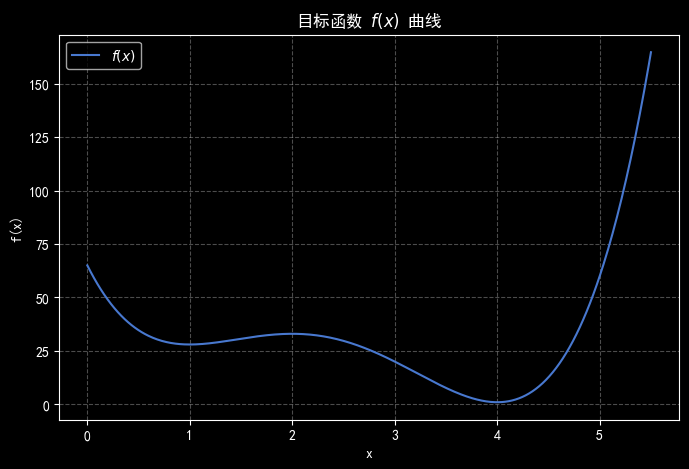

In [3]:
# 目标函数在 [0, 5.5] 上的曲线
x_vals = np.linspace(0, 5.5, 500)
y_vals = quartic_function(x_vals)

plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, label="$f(x)$")
plt.title("目标函数 $f(x)$ 曲线")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

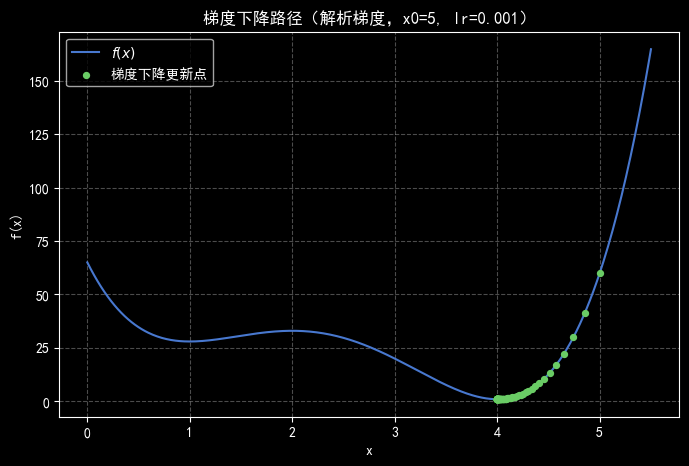

解析梯度最终 x ≈ 4.000000, 数值梯度最终 x ≈ 4.000000


In [4]:
# 使用解析梯度，初始 x0 = 5，学习率 0.001，迭代 500 次
initial_x = 5.0
lr = 1e-3
n_iters = 500
path = gradient_descent_1d(initial_x, lr, n_iters, quartic_derivative)

plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, label="$f(x)$")
plot_descent_path(path, label="梯度下降更新点")
plt.title("梯度下降路径（解析梯度，x0=5, lr=0.001）")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

# 对比数值梯度最后位置
path_numeric = gradient_descent_1d(initial_x, lr, n_iters, lambda x: numerical_derivative(x))
print(f"解析梯度最终 x ≈ {path[-1]:.6f}, 数值梯度最终 x ≈ {path_numeric[-1]:.6f}")

x=-8.162e+09 超出阈值，迭代终止。


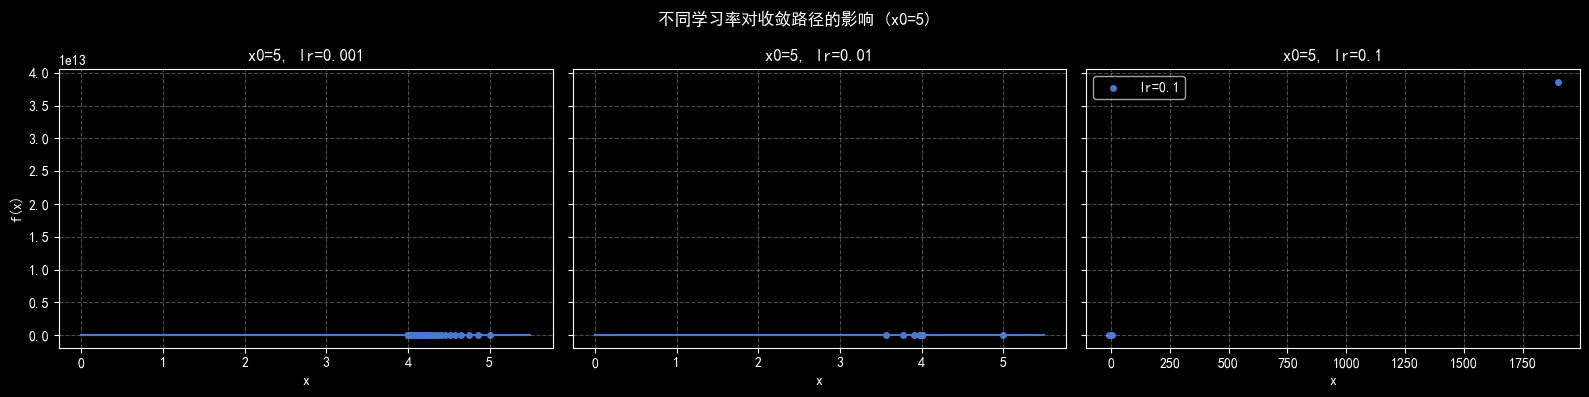

In [5]:
# 比较不同学习率在 x0 = 5 时的表现
learning_rates = [1e-3, 1e-2, 1e-1]
fig, axes = plt.subplots(1, len(learning_rates), figsize=(16, 4), sharey=True)

for ax, lr in zip(axes, learning_rates):
    path = gradient_descent_1d(5.0, lr, n_iters, quartic_derivative)
    ax.plot(x_vals, y_vals)
    ys = quartic_function(path)
    ax.scatter(path, ys, s=16, label=f"lr={lr}")
    ax.set_title(f"x0=5, lr={lr}")
    ax.set_xlabel("x")
    ax.grid(True, linestyle="--", alpha=0.3)
axes[0].set_ylabel("f(x)")
axes[-1].legend(loc="best")
plt.suptitle("不同学习率对收敛路径的影响 (x0=5)")
plt.tight_layout()
plt.show()

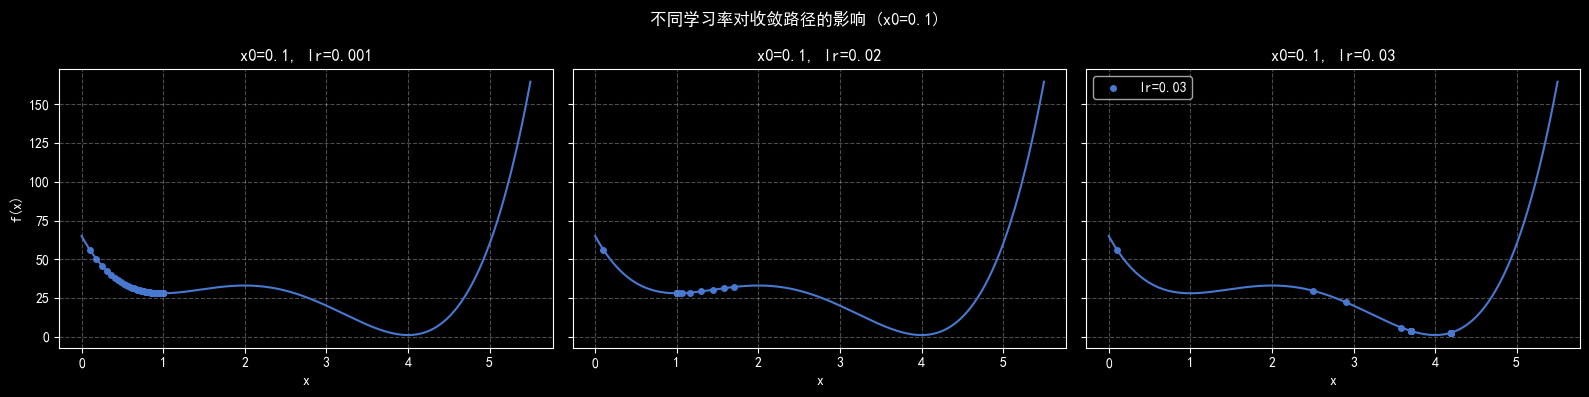

In [6]:
# 初始 x0 = 0.1，比较不同学习率的迭代效果
learning_rates_small = [1e-3, 0.02, 0.03]
fig, axes = plt.subplots(1, len(learning_rates_small), figsize=(16, 4), sharey=True)

for ax, lr in zip(axes, learning_rates_small):
    path = gradient_descent_1d(0.1, lr, n_iters, quartic_derivative)
    ax.plot(x_vals, y_vals)
    ys = quartic_function(path)
    ax.scatter(path, ys, s=16, label=f"lr={lr}")
    ax.set_title(f"x0=0.1, lr={lr}")
    ax.set_xlabel("x")
    ax.grid(True, linestyle="--", alpha=0.3)
axes[0].set_ylabel("f(x)")
axes[-1].legend(loc="best")
plt.suptitle("不同学习率对收敛路径的影响 (x0=0.1)")
plt.tight_layout()
plt.show()

## 第二部分：基于梯度下降的多元线性回归
利用 `data2.txt` 数据集（两维输入特征与一个目标量）构建多元线性回归模型。步骤包括：数据可视化、梯度与损失函数实现、梯度校验、训练过程监控以及新样本预测。

In [7]:
# 读取数据集：列分别为 [特征1, 特征2, 目标值]
data_path = Path("data2.txt")
data = np.loadtxt(data_path, delimiter=",")

X_raw = data[:, :2]  # 特征：特征1、特征2
y_raw = data[:, 2]   # 目标变量

print(f"样本数量: {X_raw.shape[0]}, 特征维度: {X_raw.shape[1]}")
print("前 5 条数据:\n", np.hstack([X_raw[:5], y_raw[:5, None]]))

样本数量: 47, 特征维度: 2
前 5 条数据:
 [[2.104e+03 3.000e+00 3.999e+05]
 [1.600e+03 3.000e+00 3.299e+05]
 [2.400e+03 3.000e+00 3.690e+05]
 [1.416e+03 2.000e+00 2.320e+05]
 [3.000e+03 4.000e+00 5.399e+05]]


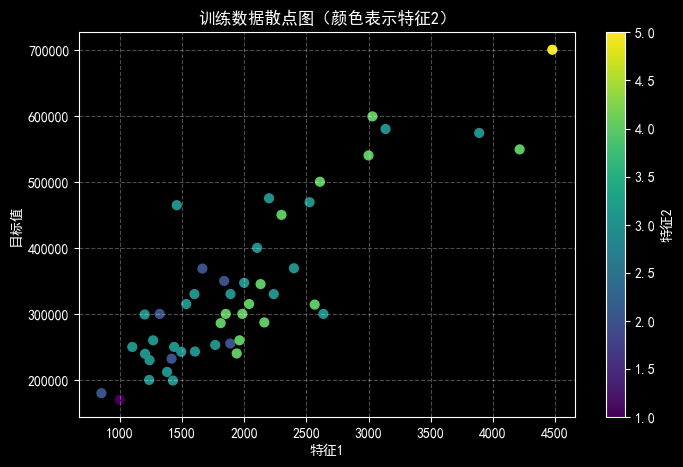

In [8]:
# 可视化特征1与目标值的关系，颜色区分特征2
plt.figure(figsize=(8, 5))
scatter = plt.scatter(X_raw[:, 0], y_raw, c=X_raw[:, 1], cmap="viridis", s=40)
plt.xlabel("特征1")
plt.ylabel("目标值")
plt.title("训练数据散点图（颜色表示特征2）")
cbar = plt.colorbar(scatter)
cbar.set_label("特征2")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

In [9]:
# 特征缩放：均值归一化，提升梯度下降效率
X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0)
X = (X_raw - X_mean) / X_std

# 添加偏置项（常数 1）
X_with_bias = np.hstack([np.ones((X.shape[0], 1)), X])
y = y_raw

# 定义损失函数（均方误差的一半）与梯度
def compute_loss(theta: np.ndarray, Xb: np.ndarray, y_true: np.ndarray) -> float:
    """计算损失函数 J(θ) = (1/2m) * Σ(hθ(x) - y)^2。"""
    m = len(y_true)
    preds = Xb @ theta
    return np.sum((preds - y_true) ** 2) / (2 * m)


def compute_gradient(theta: np.ndarray, Xb: np.ndarray, y_true: np.ndarray) -> np.ndarray:
    """解析梯度：∂J/∂θ = (1/m) * X^T (hθ(x) - y)。"""
    m = len(y_true)
    preds = Xb @ theta
    return Xb.T @ (preds - y_true) / m


def numerical_gradient(theta: np.ndarray, Xb: np.ndarray, y_true: np.ndarray, epsilon: float = 1e-4) -> np.ndarray:
    """使用有限差分验证梯度的正确性。"""
    num_grad = np.zeros_like(theta)
    for i in range(len(theta)):
        theta_plus = theta.copy()
        theta_minus = theta.copy()
        theta_plus[i] += epsilon
        theta_minus[i] -= epsilon
        loss_plus = compute_loss(theta_plus, Xb, y_true)
        loss_minus = compute_loss(theta_minus, Xb, y_true)
        num_grad[i] = (loss_plus - loss_minus) / (2 * epsilon)
    return num_grad


def gradient_descent_multi(theta_init: np.ndarray, Xb: np.ndarray, y_true: np.ndarray, lr: float, n_iters: int):
    """多元线性回归的梯度下降，返回 θ 以及损失历史。"""
    theta = theta_init.copy()
    losses = []
    for _ in range(n_iters):
        grad = compute_gradient(theta, Xb, y_true)
        theta -= lr * grad
        losses.append(compute_loss(theta, Xb, y_true))
    return theta, losses

In [10]:
# 梯度校验：随机初始化 θ，比较解析梯度与数值梯度
np.random.seed(42)
theta_test = np.random.randn(X_with_bias.shape[1])
analytic_grad = compute_gradient(theta_test, X_with_bias, y)
numeric_grad = numerical_gradient(theta_test, X_with_bias, y)

diff_norm = np.linalg.norm(analytic_grad - numeric_grad)
print("解析梯度:", analytic_grad)
print("数值梯度:", numeric_grad)
print(f"梯度差的二范数: {diff_norm:.6e}")

解析梯度: [-340412.16286032 -105763.90907278  -54708.25149081]
数值梯度: [-340412.29248047 -105763.93127441  -54708.36639404]
梯度差的二范数: 1.746340e-01


In [11]:
# 训练模型：使用学习率 0.01，迭代 1500 次
lr_multi = 0.01
n_iters_multi = 1500
theta_init = np.zeros(X_with_bias.shape[1])

theta_trained, loss_history = gradient_descent_multi(theta_init, X_with_bias, y, lr_multi, n_iters_multi)

print("训练后的 θ:", theta_trained)
print(f"最终损失: {loss_history[-1]:.4f}")

训练后的 θ: [340412.56301439 109370.05670466  -6500.61509507]
最终损失: 2043282709.9328


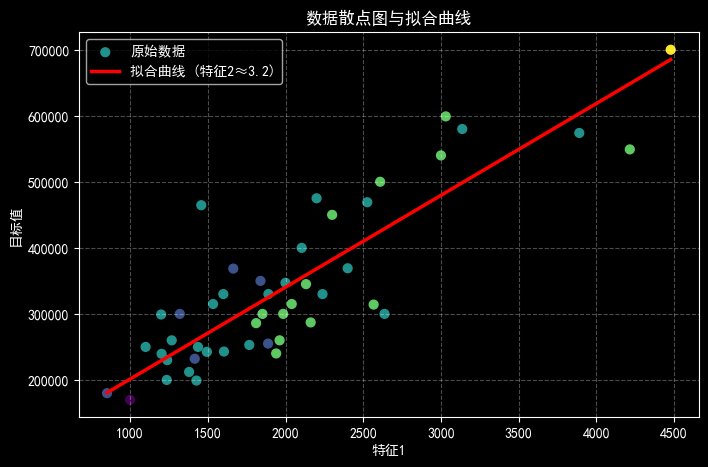

In [12]:
# 利用训练得到的参数绘制拟合结果（固定特征2为平均值）
feature1_range = np.linspace(X_raw[:, 0].min(), X_raw[:, 0].max(), 200)
avg_feature2 = X_raw[:, 1].mean()

# 构造对应的特征矩阵并执行同样的归一化
features_for_plot = np.column_stack([feature1_range, np.full_like(feature1_range, avg_feature2)])
features_norm = (features_for_plot - X_mean) / X_std
features_with_bias = np.hstack([np.ones((features_norm.shape[0], 1)), features_norm])
pred_values = features_with_bias @ theta_trained

plt.figure(figsize=(8, 5))
plt.scatter(X_raw[:, 0], y_raw, c=X_raw[:, 1], cmap="viridis", s=40, label="原始数据")
plt.plot(feature1_range, pred_values, color="red", linewidth=2.5, label=f"拟合曲线 (特征2≈{avg_feature2:.1f})")
plt.xlabel("特征1")
plt.ylabel("目标值")
plt.title("数据散点图与拟合曲线")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

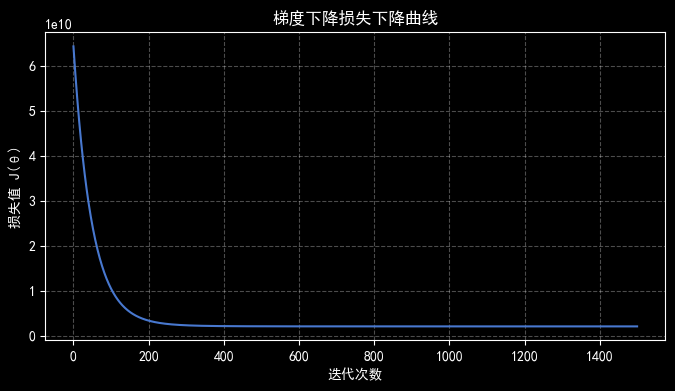

In [13]:
# 绘制梯度下降过程中损失函数的变化
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel("迭代次数")
plt.ylabel("损失值 J(θ)")
plt.title("梯度下降损失下降曲线")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

In [14]:
# 基于训练好的参数输出预测值
new_samples = np.array([
    [1650, 3],
    [2500, 4],
    [1200, 2]
], dtype=float)

new_samples_norm = (new_samples - X_mean) / X_std
new_samples_with_bias = np.hstack([np.ones((new_samples_norm.shape[0], 1)), new_samples_norm])
predictions = new_samples_with_bias @ theta_trained

np.round(predictions, 2)

array([293098.47, 402708.73, 239132.92])

## 问题讨论
- **实验收获**：通过一维四次函数的梯度下降演示，熟悉了学习率、初始值对收敛路径的影响，并在多元线性回归任务中掌握了特征缩放、梯度推导与数值校验的完整流程。
- **遇到的问题**：在较大学习率下梯度下降出现发散，数值梯度计算阶段也出现过溢出风险；此外，原始数据量纲差异较大，直接训练收敛速度较慢。
- **解决思路**：为一维梯度下降引入发散阈值与异常提示，便于定位不稳定的学习率；多元情况下采用均值归一化并进行梯度数值对比验证公式正确性，最终稳定获得收敛结果与可靠预测。